In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Tuple, Optional, Union

import gcsfs
import os
import sys
import json
from pprint import pprint

#fs = gcsfs.GCSFileSystem()
#fs.ls("gs://leap-persistent/sammyagrawal/") # List files in the bucket where the E3SM-MMF dataset is stored

In [2]:
sys.path.append(os.path.abspath(os.path.join('../diffusionsim')))
import torch
import torch.nn as nn
import xbatcher
import torch.nn.functional as F

import diffusers
import physicsnemo
import diffusionsim as diff
import diffusionsim.training_utils as tru
from diffusionsim.climsim_utils import imagify
from diffusionsim import mydatasets as data
#import diffusionsim.evaluations as evals

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [4]:
diffusers.__file__

'/srv/conda/envs/notebook/lib/python3.12/site-packages/diffusers/__init__.py'

In [5]:
torch.manual_seed(0)
np.random.seed(0)

## Data

In [218]:
source = "local-vzarr" if True else "gcsfs"

dconfig = tru.my_dconfig(source, "v1", in_notebook=True, shuffle_indices=False, 
                        dataset_type="climsim", batch_size=64, use_tendencies=False)
dconfig.train_test_split = [1.0]
dconfig.phases = ["train"]
pprint(dconfig)

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           num_epochs=10,
           phases=['train'],
           train_test_split=[1.0],
           dataloader_params=DataLoaderParams(batch_size=64,
                                              shuffle=True,
                                              num_workers=0,
                                              prefetch_factor=None,
                                              persistent_workers=False,
                                              multiprocessing_context=None,
                                              pin_memory=False),
           data_vars='v1',
           use_tendencies=False,
           norm_info='image',
           chunksize={},
           shuffle_indices=False,
           distributed_training=False,
           checkpoint_best_epoch=True,
           checkpoin

In [219]:
dataloaders, [indices] = data.load_dataloaders(dconfig, log=False, indices=None)

In [222]:
dl = dataloaders[0]
ds = dl.dataset
dutils = ds.dutils

In [221]:
x, y = next(iter(dl))
## imagify(x, ds.dutils, 'x', 1).shape

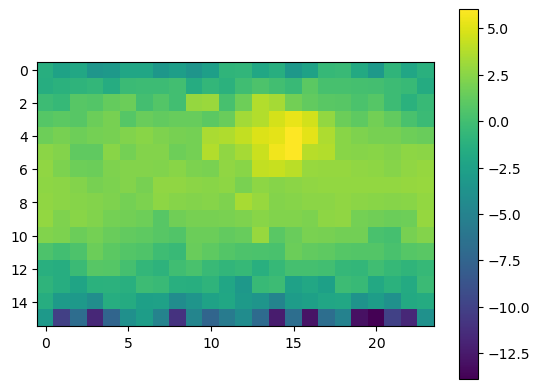

In [11]:
plt.imshow(imagify(y, ds.dutils, 'y', 2)[0, 59].cpu().detach().numpy())
plt.colorbar()

In [223]:
def plot_profile(data, var_index=None, ax=None, title='', **kwargs):
    data = np.asarray(data)
    assert data.ndim < 4, "no more than 3d"
    if data.ndim == 3:
        assert var_index is not None, "need to specify variable"
        data = data[:, var_index, :]
    elif(data.ndim == 2 and data.shape[0] == 10):
        data = data[var_index]
    levels = np.arange(data.shape[-1])
    if ax is None:
        fig, ax = plt.subplots()
    if data.ndim == 1:
        ax.plot(data, levels, **kwargs)
    else:
        for profile in data: 
            ax.plot(profile, levels, **kwargs) 
    ax.invert_yaxis()
    ax.set_ylabel("Level index (0 = top)")
    ax.set_title(title)
    if var_index is not None: 
        ax.set_xlabel(ds.target_vars[var_index])

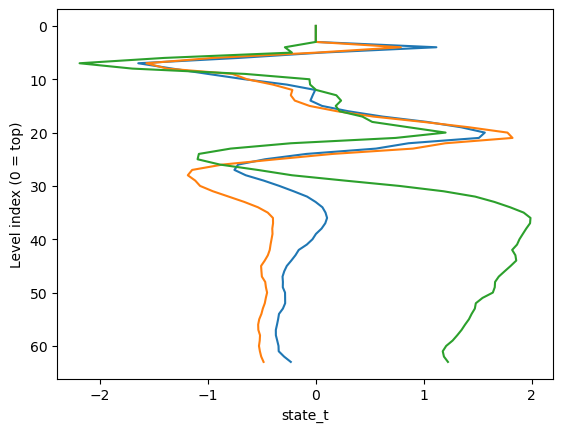

In [224]:
plot_profile(imagify(y, ds.dutils, 'y', 1)[0:3], 0)

# How Diffusion Works

### Sampling $x_t$ from markov chain
[DDPM Paper](https://arxiv.org/pdf/2006.11239)
Given a **fixed** noise schedule $\{\beta_1, ..., \beta_T\}$, we can define $\alpha_t:= 1- \beta_t$ and $\bar{\alpha_t} = \prod_{s=1}^t \alpha_s$

Giving rules for products of gaussians, we can conveniently sample from any arbitrary node in the Markov Chain as long as we condition on $x_0$. $$q(x_t|x_0) = \mathcal N(\sqrt{\bar{\alpha_t}} \cdot x_0, (1-\bar{\alpha_t}) I)$$

Given a sample $\epsilon$ drawn from a standard gaussian, we leverage this to reparameterize $$x_t(x_0, \epsilon) = \sqrt{\bar{\alpha_t}} \cdot x_0 + \sqrt{1-\bar{\alpha_t}} \cdot \epsilon$$


The loss, which can also be interpreted as training a noise-conditional score based model, is (14) from the paper: $$L_{simple} := \mathbb{E} [||\epsilon - \epsilon_\theta(x_t(x_0, \epsilon, t), t)||^2]$$

In [14]:
IMAGE_DIM = 1
input_sample = imagify(y, ds.dutils, 'y', IMAGE_DIM)
input_sample.shape

torch.Size([49152, 10, 64])

In [15]:
train_steps = 100

In [16]:
scheduler_type = "ddpm" 
scheduler_params = tru.SchedulerParams(num_train_timesteps=train_steps)
scheduler_params

SchedulerParams(num_train_timesteps=100, beta_schedule='linear', clip_sample=False, clip_sample_range=4.0, beta_end=0.02)

In [17]:
scheduler_class = diffusers.DDPMScheduler if scheduler_type=="ddpm" else diffusers.DDIMScheduler
noise_scheduler = scheduler_class(**asdict(scheduler_params))

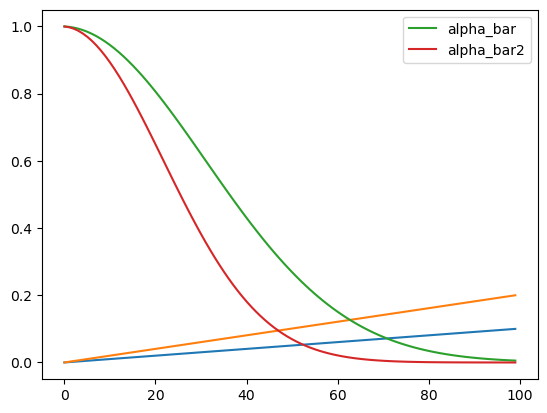

In [18]:

scheduler = diffusers.DDPMScheduler(
    num_train_timesteps=100,
    beta_start=0.0001,
    beta_end=0.1,  # Changed from 0.01 to 0.2
    beta_schedule="linear",
)
scheduler2 = diffusers.DDPMScheduler(
    num_train_timesteps=100,
    beta_start=0.0001,
    beta_end=0.2,  # Changed from 0.01 to 0.2
    beta_schedule="linear",
)
plt.plot(scheduler.betas) # how much noise
plt.plot(scheduler2.betas)
plt.plot(scheduler.alphas_cumprod, label='alpha_bar') # how much signal vs noise
plt.plot(scheduler2.alphas_cumprod, label='alpha_bar2')
plt.legend()
plt.show()

In [ ]:
print(noise_scheduler.config.num_train_timesteps)
print(noise_scheduler.timesteps)
noise_scheduler.set_timesteps(10)
print(noise_scheduler.timesteps)
noise_scheduler.set_timesteps(100)

In [ ]:
def get_alpha_t_manual(t, scheduler=noise_scheduler):
    a = 1
    for s in range(t+1):
        a = a * (1-scheduler.betas[s])
    return(a)
print(get_alpha_t_manual(5) - noise_scheduler.alphas_cumprod[5])
noise_scheduler.alphas_cumprod[:6]

In [ ]:
fig, axes = plt.subplots(1, 2, sharex=True)
axes[1].plot(noise_scheduler.alphas_cumprod, label='alpha_bar')
axes[0].plot(noise_scheduler.betas, label='betas', color='orange')
plt.legend()
plt.show()

In [ ]:
def sample_xt(x0, t):
    eps = torch.randn(x0.shape) # BS x C x H x W
    xt = noise_scheduler.add_noise(x0, eps, torch.LongTensor(t)) # noisy image
    return(xt, eps)

In [ ]:
t = 50
x50, eps = sample_xt(input_sample, [t])

In [ ]:
at = noise_scheduler.alphas_cumprod[t]
x50_manual = torch.sqrt(at) * input_sample + torch.sqrt(1-at)*eps

In [ ]:
loss_fn = torch.nn.MSELoss()

In [ ]:
(x50_manual == x50).all() # the same! 

Loss called to match model prediction to actual noise used to generate noisy latent. 

training_loss = loss_fn(model(x_t, t).sample, epsilon_noise_sample)

In [ ]:
eps.shape, input_sample.shape

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
var_index = 0
if IMAGE_DIM == 1:
    
    plot_profile(input_sample[0, var_index], ax=axes[0], title="Original", )
    
    plot_profile(x50[0, var_index], ax=axes[1], title="Noisy", var_index=0)
    
    plot_profile(eps[0, var_index], ax=axes[2], title="Noise", var_index=0)
    
    plt.tight_layout()
    plt.show()
elif IMAGE_DIM == 2:
    im0 = axes[0].imshow(input_sample.permute(0, 2, 3, 1).cpu().numpy()[0, :, :, 59], 'viridis')
    axes[0].title.set_text("x0 original sample")
    axes[0].set_axis_off()
    
    im1 = axes[1].imshow(x50.permute(0, 2, 3, 1).cpu().numpy()[0, :, :, 59], 'viridis')
    axes[1].set_axis_off()
    axes[1].title.set_text("x50 noisy sample")
    
    im2 = axes[2].imshow(eps[0, 59, :, :], 'viridis')
    axes[2].set_axis_off()
    axes[2].title.set_text("Noise Level eps")
    
    fig.colorbar(im0, ax=axes[0], orientation='vertical')
    fig.colorbar(im1, ax=axes[1], orientation='vertical')
    fig.colorbar(im2, ax=axes[2], orientation='vertical')
    plt.show()

In [ ]:
x100, eps = sample_xt(input_sample, [99])

In [ ]:
if IMAGE_DIM == 1:
    plot_profile(x100[26, var_index], color='orange')
else:
    plt.imshow(x100[0, 59])

### How much Noise Destroys Sample? 

$$ \mathbb{E}[(X+\epsilon)^T (X+\epsilon)] = \mathbb{E}[(X^T X +\epsilon^T \epsilon)]$$
$$ = V \Lambda V^{-1} + V \sigma^2 I V^{-1} = V (\Lambda + \sigma^2 I) V^{-1}$$

In [ ]:
print(input_sample.shape)

X = input_sample.reshape(128, -1)
X.shape

In [ ]:
plt.hist(X.flatten())

In [ ]:
M = torch.matmul(X, torch.transpose(X, 0, 1)).numpy()
print(f"M symmetric: {np.isclose(M, M.T).all()}")
M.shape

In [ ]:
eig, Q = np.linalg.eigh(M)

In [ ]:
Mhat = np.dot(np.dot(Q, np.diag(eig)), Q.T)

plt.imshow(Mhat - M)
plt.colorbar()

In [ ]:
eig[-5:]

These eigenvalues seem really high...

## How Reverse Diffusion with trained model works

Given $\epsilon$, we can obtain the distribution for a reverse diffusion step. Recall that $$p_\theta(x_{t-1} | x_t) := \mathcal{N}(x_{t-1}; \mu_\theta(x_t, t), \Sigma_\theta=\sigma_t^2 I)$$
where $\sigma_t^2=\beta_t$ is a common choice. 


$$x_{t-1} =\dfrac{1}{\alpha_t}\left(x_t - \dfrac{\beta_t}{\sqrt{1-\alpha_t}} \epsilon_\theta(x_t, t)\right) + \sigma_t z \,\,\,\,\,\, z \sim \mathcal N(0, I)$$

More simply, since $x_t = \sqrt{1 - \beta_t} x_{t-1} + \sqrt{\beta_t} \sigma_t$, then $x_{t-1} = \dfrac{1}{\alpha_t}(x_t - \sqrt{\beta_t} \epsilon_\theta)$

In [ ]:
noise_scheduler.timesteps

In [ ]:
x50.shape, eps.shape

In [ ]:
gen = torch.Generator()

In [ ]:
x49 = noise_scheduler.step(eps, timestep=50, sample=x50, generator=gen).prev_sample
x49.shape

In [ ]:
step = noise_scheduler.step(eps, timestep=50, sample=x50, generator=gen)
x49b, x0_hat = step.prev_sample, step.pred_original_sample


In [ ]:
sigma_diff = (x49 - x49b).numpy() / np.sqrt(noise_scheduler.betas[50])
print(sigma_diff.shape)
if IMAGE_DIM == 1:
    plot_profile(sigma_diff[0,0])
else:
    plt.imshow(sigma_diff[0,59,:,:]/2)
    plt.colorbar()

In [ ]:
def manual_inference_step(epsilon, t, xt, scheduler):
    # x t-1
    bt = noise_scheduler.betas[t]
    x = xt - np.sqrt(bt) * epsilon
    x = x / np.sqrt(1 - bt)
    return(x)

In [ ]:
def run_pipeline(model, scheduler):
    # get x t-1 given x_t
    input =  torch.randn(input_sample.shape)
    for t in scheduler.timesteps:
        with torch.no_grad():
            noisy_residual = model(input, t).sample
        previous_noisy_sample = scheduler.step(noisy_residual, t, input).prev_sample
        input = previous_noisy_sample


In [ ]:
x49_manual = manual_inference_step(eps, 50, x50, noise_scheduler)

In [ ]:
x49_manual.shape

# U Net Model

Ok so we have our noisy dataset and our well defined task. Let's explore the model!

- U Net at its core is a convolution based encoder decoder architecture that progressively reduces height/width dimensionality but adds channels with "down blocks" and rescales with "upblocks". Residual connections as well
- Timestep is fed into noise-conditional model via a time embedding. "temb" is a parameter in all the downsample blocks


Resources: 
- [Time Embeddings and conditioning](https://varun-ml.github.io/posts/diffusion-models/denoising-diffusion-models-2/)

In [17]:
import inspect
def pass_config(func, data_class):
    # only pass model config params that function takes in
    accepted_params = inspect.signature(func).parameters
    filtered_kwargs = {k: v for k, v in asdict(data_class).items() if k in accepted_params}
    return func(**filtered_kwargs)

## 1D Diffusion

[Source code](https://github.com/huggingface/diffusers/blob/v0.34.0/src/diffusers/models/unets/unet_1d.py#L41)

[Projection Embedding src](https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/embeddings.py#L1321)

In [18]:
img = torch.randn(8, 10, 64).to(device) # imagify(y, ds.dutils, 'y', 1).to(device)
img.shape, img.device

(torch.Size([8, 10, 64]), device(type='cuda', index=0))

In [19]:
@dataclass
class DiffusionModelConfig1d:
    in_channels: int = 10
    out_channels: int = 10
    down_block_types: Tuple[str] = ("DownResnetBlock1D", "AttnDownBlock1D", "DownBlock1D")
    up_block_types: Tuple[str] = ("UpResnetBlock1D", "AttnUpBlock1D", "UpBlock1D")
    norm_num_groups: int = 8
    layers_per_block: int = 1
    act_fn: str = "silu" # https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/activations.py#L27
    freq_shift: float = 0.0 # fourier freq shift
    use_timestep_embedding: bool = True
    block_out_channels: Tuple[int] = (32, 32, 64) # (32, 32, 64
    extra_in_channels: int = 0

unet_params = DiffusionModelConfig1d()
pprint(unet_params)

DiffusionModelConfig1d(in_channels=10,
                       out_channels=10,
                       down_block_types=('DownResnetBlock1D',
                                         'AttnDownBlock1D',
                                         'DownBlock1D'),
                       up_block_types=('UpResnetBlock1D',
                                       'AttnUpBlock1D',
                                       'UpBlock1D'),
                       norm_num_groups=8,
                       layers_per_block=1,
                       act_fn='silu',
                       freq_shift=0.0,
                       use_timestep_embedding=True,
                       block_out_channels=(32, 32, 64),
                       extra_in_channels=0)


In [20]:
diff.models.ClimsimUNet1DModel

diffusionsim.models.ClimsimUNet1DModel

In [23]:
unet = pass_config(diff.models.ClimsimUNet1DModel, unet_params).to(device)
self = unet

In [24]:
self.device

device(type='cuda', index=0)

In [25]:
unet(img, 0).sample.shape, img.shape

(torch.Size([8, 10, 64]), torch.Size([8, 10, 64]))

### Forward Pass

self.time_proj is defined [here](https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/embeddings.py#L1321)

self.time_mlp is defined [here](https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/embeddings.py#L1254)

Hardcoded values worth looking at: [source code](https://github.com/huggingface/diffusers/blob/v0.34.0/src/diffusers/models/unets/unet_1d.py#L41)

1. Why is the embedding size for the GaussianFourierProjection always 8? --> forces block_out_channels[0] to be 8
2. Play 

In [46]:
sample = img.to("cpu")
sample.shape, sample.device

(torch.Size([8, 10, 64]), device(type='cpu'))

In [26]:
timesteps = torch.tensor([1, 7, 4, 8], dtype=torch.long)
timesteps[:,None].shape

timestep = 0
timesteps = timestep
if not torch.is_tensor(timesteps):
    timesteps = torch.tensor([timesteps], dtype=torch.long, device=sample.device)
elif torch.is_tensor(timesteps) and len(timesteps.shape) == 0:
    timesteps = timesteps[None].to(sample.device)

timesteps

tensor([0])

In [27]:
timestep_embed = self.time_proj(timesteps)
print(self.time_proj.weight.shape)  # GaussianFP(embedding_size=block_out_channels[0], scale=1.0) 
timestep_embed.shape # 2 times the weight, cat[sin, cos]

torch.Size([32])


torch.Size([1, 64])

In [28]:
if True and self.config.use_timestep_embedding:
    timestep_embed = self.time_mlp(timestep_embed.to(sample.dtype)) # (in=timestep.input_dim (2*block_out_channels[0]), out=block_out_channels[0]
else:
    timestep_embed = timestep_embed[..., None] # [1, C, 1]
    timestep_embed = timestep_embed.repeat([1, 1, sample.shape[2]]).to(sample.dtype) # [1, C, lev 64]
timestep_embed = timestep_embed.broadcast_to((sample.shape[:1] + timestep_embed.shape[1:])) # [N, C, 64]
timestep_embed.shape

torch.Size([8, 32])

In [29]:
i, j = 2, 6
timestep_embed[i] == timestep_embed[j]

tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True])

In [30]:
temb = timestep_embed
sample.shape, timestep_embed.shape

(torch.Size([8, 10, 64]), torch.Size([8, 32]))

In [31]:
sample.device

device(type='cpu')

In [32]:
# 2. down
down_block_res_samples = ()
for downsample_block in self.down_blocks:
    sample, res_samples = downsample_block(hidden_states=sample, temb=timestep_embed)
    print(sample.shape, type(res_samples), len(res_samples), res_samples[0].shape)
    down_block_res_samples += res_samples

torch.Size([8, 32, 32]) <class 'tuple'> 1 torch.Size([8, 32, 32])
torch.Size([8, 32, 16]) <class 'tuple'> 1 torch.Size([8, 32, 16])
torch.Size([8, 64, 8]) <class 'tuple'> 1 torch.Size([8, 64, 8])


In [33]:
print((sample == res_samples[0]).all())
sample.shape, res_samples[0].shape

tensor(True)


(torch.Size([8, 64, 8]), torch.Size([8, 64, 8]))

In [34]:
print(len(down_block_res_samples))
for i in down_block_res_samples:
    print(i.shape)

3
torch.Size([8, 32, 32])
torch.Size([8, 32, 16])
torch.Size([8, 64, 8])


In [40]:
sample = self.mid_block(sample, timestep_embed)

In [41]:
sample.shape, down_block_res_samples[-1].shape, type(self.up_blocks[0])

(torch.Size([8, 64, 8]),
 torch.Size([8, 64, 8]),
 diffusionsim.blocks_1d.UpResnetBlock1D)

In [42]:
self.up_blocks[1].resnets[1]

ResConvBlock(
  (conv_1): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (group_norm_1): GroupNorm(1, 32, eps=1e-05, affine=True)
  (gelu_1): GELU(approximate='none')
  (conv_2): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (group_norm_2): GroupNorm(1, 32, eps=1e-05, affine=True)
  (gelu_2): GELU(approximate='none')
)

In [43]:
sample_test = self.up_blocks[0](sample, res_hidden_states_tuple=down_block_res_samples[-1:], temb=timestep_embed).detach().cpu().clone()
down_block_res_samples_test = down_block_res_samples[:-1]

In [44]:
sample_test.shape, len(down_block_res_samples_test), down_block_res_samples_test[-1].shape

(torch.Size([8, 32, 16]), 2, torch.Size([8, 32, 16]))

In [222]:
sample_test2 = self.up_blocks[1].to('cpu')(sample_test, res_hidden_states_tuple=res_sample_test, temb=timestep_embed.to('cpu')).detach().cpu().clone()
down_block_res_samples_test2 = down_block_res_samples_test[:-1]
res_sample_test2 = (down_block_res_samples_test2[-1].to("cpu"),)

In [225]:
len(res_sample_test2), res_sample_test2[0].shape, sample_test2.shape

(1, torch.Size([8, 32, 64]), torch.Size([8, 32, 32]))

In [231]:
(res_sample_test2[0] == down_block_res_samples[0].to("cpu")).all()

tensor(True)

In [164]:
sample_test.shape, sample_test2.shape

(torch.Size([8, 32, 16]), torch.Size([8, 32, 32]))

In [234]:
self.down_blocks[0]

DownResnetBlock1D(
  (resnets): ModuleList(
    (0): ResidualTemporalBlock1D(
      (conv_in): Conv1dBlock(
        (conv1d): Conv1d(10, 32, kernel_size=(5,), stride=(1,), padding=(2,))
        (group_norm): GroupNorm(8, 32, eps=1e-05, affine=True)
        (mish): Mish()
      )
      (conv_out): Conv1dBlock(
        (conv1d): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
        (group_norm): GroupNorm(8, 32, eps=1e-05, affine=True)
        (mish): Mish()
      )
      (time_emb_act): Mish()
      (time_emb): Linear(in_features=32, out_features=32, bias=True)
      (residual_conv): Conv1d(10, 32, kernel_size=(1,), stride=(1,))
    )
    (1): ResidualTemporalBlock1D(
      (conv_in): Conv1dBlock(
        (conv1d): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
        (group_norm): GroupNorm(8, 32, eps=1e-05, affine=True)
        (mish): Mish()
      )
      (conv_out): Conv1dBlock(
        (conv1d): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))

In [165]:
sample_test3 = self.up_blocks[2](sample_test2, res_hidden_states_tuple=down_block_res_samples_test2[-1:], temb=timestep_embed)
down_block_res_samples_test3 = down_block_res_samples_test2[:-1]

RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 32 but got size 64 for tensor number 1 in the list.

In [148]:
sample_test = sample.cpu().detach().clone()
res_samples_test = (res_samples[0].cpu().detach().clone(),)
down_block_res_samples_test = (down_block_res_samples[0].cpu().detach().clone(),)

In [103]:
bad_block = self.up_blocks[2].to("cpu")
bad_block

UpBlock1D(
  (resnets): ModuleList(
    (0): ResConvBlock(
      (conv_skip): Conv1d(64, 32, kernel_size=(1,), stride=(1,), bias=False)
      (conv_1): Conv1d(64, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (group_norm_1): GroupNorm(1, 32, eps=1e-05, affine=True)
      (gelu_1): GELU(approximate='none')
      (conv_2): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (group_norm_2): GroupNorm(1, 32, eps=1e-05, affine=True)
      (gelu_2): GELU(approximate='none')
    )
    (1): ResConvBlock(
      (conv_1): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (group_norm_1): GroupNorm(1, 32, eps=1e-05, affine=True)
      (gelu_1): GELU(approximate='none')
      (conv_2): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (group_norm_2): GroupNorm(1, 32, eps=1e-05, affine=True)
      (gelu_2): GELU(approximate='none')
    )
    (2): ResConvBlock(
      (conv_skip): Conv1d(32, 10, kernel_size=(1,), stride=(1,), bias=False)
      (co

In [149]:
#sample = bad_block(sample_test, res_hidden_states_tuple=res_samples_test, temb=timestep_embed.to("cpu"))

In [107]:
res_hidden_states_tuple = res_samples_test
temb = timestep_embed.to("cpu")
hidden_states = sample_test

In [108]:
res_hidden_states = res_hidden_states_tuple[-1]
hidden_states = torch.cat([hidden_states, res_hidden_states], dim=1)

RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 32 but got size 16 for tensor number 1 in the list.

In [110]:
hidden_states.shape, res_hidden_states.shape

(torch.Size([8, 32, 32]), torch.Size([8, 32, 16]))

## 2D Diffusion

In [ ]:
@dataclass
class DiffusionModelConfig:
    model_type: str = "diffusion"
    image_height = 16
    image_width  = 24
    in_channels: int = 128
    latent_dims: int = 16
    out_channels: int = 128
    block_out_channels: Tuple = field(default_factory=lambda: (32, 64, 64, 128))  # num output channel for each UNet block
    down_blocks: Tuple = field(default_factory=lambda: (
        "DownBlock2D",  # a regular ResNet downsampling block
        "DownBlock2D",
        "AttnDownBlock2D",  # a ResNet downsampling block with spatial self-attention
        "DownBlock2D",
    ))
    up_blocks: Tuple = field(default_factory=lambda: (
        "UpBlock2D",  # a regular ResNet upsampling block
        "AttnUpBlock2D",  # a ResNet upsampling block with spatial self-attention
        "UpBlock2D",
        "UpBlock2D",
    ))

In [ ]:
unet = tru.UNetParams()
unet.block_out_channels = (128, 256, 512)
unet.down_block_types = ("DownBlock2D", "AttnDownBlock2D", "DownBlock2D")
unet.up_block_types = ("UpBlock2D", "AttnUpBlock2D", "UpBlock2D")
unet.layers_per_block = 1
unet.norm_num_groups = 2

In [ ]:
scheduler = tru.SchedulerParams()

In [ ]:
mconfig = tru.ModelConfig()
mconfig.model_type = "ddpm_diffusion"
mconfig.unet = unet
mconfig.scheduler = scheduler
pprint(asdict(mconfig))

#### Regular Model (no latent space)

In [ ]:
mconfig = DiffusionModelConfig()
mconfig

In [ ]:
model = load_model(mconfig, device)

In [ ]:
#print(isinstance(layers[1], diffusers.models.embeddings.Timesteps))
t = torch.tensor([1, 2, 3, 4])

In [ ]:
input_sample.device

In [ ]:
output = model(input_sample.to(device), timestep=0)
output.sample.shape

In [ ]:
plt.imshow(output.sample[0].cpu().detach().numpy()[59])
plt.title(f"Predicted {train_ds.mlo[59].item()}")
plt.colorbar()
plt.show()

# Zeyuan UNet

In [10]:
from typing import Any, Dict, List, Optional
import numpy as np
import torch
from torch.nn.functional import silu

def weight_init(shape: tuple, mode: str, fan_in: int, fan_out: int):
    if mode == "xavier_uniform":
        return np.sqrt(6 / (fan_in + fan_out)) * (torch.rand(*shape) * 2 - 1)
    if mode == "xavier_normal":
        return np.sqrt(2 / (fan_in + fan_out)) * torch.randn(*shape)
    if mode == "kaiming_uniform":
        return np.sqrt(3 / fan_in) * (torch.rand(*shape) * 2 - 1)
    if mode == "kaiming_normal":
        return np.sqrt(1 / fan_in) * torch.randn(*shape)
    raise ValueError(f'Invalid init mode "{mode}"')


In [11]:
class Linear(torch.nn.Module):
    def __init__(
        self,
        in_features: int,
        out_features: int,
        bias: bool = True,
        init_mode: str = "kaiming_normal",
        init_weight: int = 1,
        init_bias: int = 0,
    ):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        init_kwargs = dict(mode=init_mode, fan_in=in_features, fan_out=out_features)
        self.weight = torch.nn.Parameter(
            weight_init([out_features, in_features], **init_kwargs) * init_weight
        )
        self.bias = (
            torch.nn.Parameter(weight_init([out_features], **init_kwargs) * init_bias)
            if bias
            else None
        )

    def forward(self, x):
        x = x @ self.weight.to(dtype=x.dtype, device=x.device).t()
        if self.bias is not None:
            x = x.add_(self.bias.to(dtype=x.dtype, device=x.device))
        return x

In [108]:
class Conv1d(torch.nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel: int,
        bias: bool = True,
        up: bool = False,
        down: bool = False,
        resample_filter: Optional[List[int]] = None,
        fused_resample: bool = False,
        init_mode: str = "kaiming_normal",
        init_weight: float = 1.0,
        init_bias: float = 0.0,
    ):
        if up and down:
            raise ValueError("Both 'up' and 'down' cannot be true at the same time.")

        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel = kernel
        resample_filter = resample_filter if resample_filter is not None else [1, 1] 
        self.up = up
        self.down = down
        self.fused_resample = fused_resample
        init_kwargs = dict(
            mode=init_mode,
            fan_in=in_channels * kernel,
            fan_out=out_channels * kernel,
        )
        self.weight = (
            torch.nn.Parameter(
                weight_init([out_channels, in_channels, kernel], **init_kwargs)
                * init_weight
            )
            if kernel
            else None
        )
        self.bias = (
            torch.nn.Parameter(weight_init([out_channels], **init_kwargs) * init_bias)
            if kernel and bias
            else None
        )
        # f = torch.as_tensor(resample_filter, dtype=torch.float32)
        # f = f.unsqueeze(0).unsqueeze(1) / f.sum()
        f = torch.tensor(resample_filter, dtype=torch.float32).unsqueeze(0).unsqueeze(1) / sum(resample_filter)
        self.register_buffer("resample_filter", f if up or down else None)

    def forward(self, x):
        w = self.weight.to(dtype=x.dtype, device=x.device) if self.weight is not None else None
        b = self.bias.to(dtype=x.dtype, device=x.device) if self.bias is not None else None

        # f = self.resample_filter if self.resample_filter is not None else torch.tensor([], dtype=x.dtype, device=x.device)
        # w_pad = w.shape[-1] // 2 if w is not None else 0
        # f_pad = (f.size(-1) - 1) // 2 if f.numel() > 0 else 0  # Check for empty tensor

        # Directly use self.resample_filter without creating an empty tensor
        f = self.resample_filter

        w_pad = w.shape[-1] // 2 if w is not None else 0
        # Adjust f_pad calculation based on whether f is None or not
        f_pad = (f.size(-1) - 1) // 2 if f is not None else 0  # Use f directly
        # Adjust convolution operations based on the existence of f
        if f is not None:

            if self.fused_resample and self.up and w is not None:
                x = torch.nn.functional.conv_transpose1d(
                    x,
                    f.repeat(self.in_channels, 1, 1) * 2,
                    groups=self.in_channels,
                    stride=2,
                    padding=max(f_pad - w_pad, 0),
                )
                x = torch.nn.functional.conv1d(x, w, padding=max(w_pad - f_pad, 0))
            elif self.fused_resample and self.down and w is not None:
                x = torch.nn.functional.conv1d(x, w, padding=w_pad + f_pad)
                x = torch.nn.functional.conv1d(
                    x,
                    f.repeat(self.out_channels, 1, 1),
                    groups=self.out_channels,
                    stride=2,
                )
            else:
                if self.up:
                    x = torch.nn.functional.conv_transpose1d(
                        x,
                        f.repeat(self.in_channels, 1, 1) * 2,
                        groups=self.in_channels,
                        stride=2,
                        padding=f_pad,
                    )
                if self.down:
                    x = torch.nn.functional.conv1d(
                        x,
                        f.repeat(self.in_channels, 1, 1),
                        groups=self.in_channels,
                        stride=2,
                        padding=f_pad,
                    )
                if w is not None:
                    x = torch.nn.functional.conv1d(x, w, padding=w_pad)

        else:            
            if w is not None:
                x = torch.nn.functional.conv1d(x, w, padding=w_pad)
        if b is not None:
            x = x.add_(b.reshape(1, -1, 1))
        return x

In [136]:
x = torch.broadcast_to(torch.arange(64), (4, 10, 64)).to(dtype=torch.float32)
conv = self = Conv1d(10, 14, 4)

In [137]:
w = conv.weight.to(dtype=x.dtype, device=x.device)
b = conv.bias.to(dtype=x.dtype, device=x.device)
y = conv(x) # torch.nn.functional.conv1d(x, w, padding=w_pad) + b.reshape(1, -1, 1)
w_pad = w.shape[-1] // 2


2

In [147]:

def convolve(kernel: torch.Tensor, seq: torch.Tensor, padding: int = 0) -> torch.Tensor:
    K = kernel.shape[0]
    seq_padded = F.pad(seq[None, None, :], (padding, padding))  # shape (1,1,L+2p)
    seq_padded = seq_padded[0,0]  # back to 1D
    out_len = seq_padded.shape[0] - K + 1
    out = torch.empty(out_len, dtype=seq.dtype, device=seq.device)

    for i in range(out_len):
        window = seq_padded[i:i+K]
        out[i] = (window * kernel).sum()

    return out

In [158]:
b, i, j = 0, 12, 8

out = 0
for c in range(x.shape[1]):
    out += convolve(w[i,c], x[b,c], w_pad)
torch.allclose(out, y[b,i])

True

In [152]:
y[0,0]

tensor([  0.2793,  -0.2044,   0.3575,   1.6519,   2.9464,   4.2409,   5.5353,
          6.8298,   8.1242,   9.4187,  10.7131,  12.0076,  13.3021,  14.5965,
         15.8910,  17.1854,  18.4799,  19.7744,  21.0688,  22.3633,  23.6577,
         24.9522,  26.2466,  27.5411,  28.8356,  30.1300,  31.4245,  32.7189,
         34.0134,  35.3078,  36.6023,  37.8968,  39.1912,  40.4857,  41.7801,
         43.0746,  44.3690,  45.6635,  46.9580,  48.2524,  49.5469,  50.8414,
         52.1358,  53.4303,  54.7247,  56.0192,  57.3136,  58.6081,  59.9025,
         61.1970,  62.4915,  63.7859,  65.0804,  66.3748,  67.6693,  68.9638,
         70.2582,  71.5527,  72.8471,  74.1416,  75.4361,  76.7305,  78.0249,
         61.4468, 111.2917], grad_fn=<SelectBackward0>)

In [150]:
y.shape, x.shape, w.shape

(torch.Size([4, 14, 65]), torch.Size([4, 10, 64]), torch.Size([14, 10, 4]))

In [142]:
out.shape

torch.Size([65])

In [133]:
f = torch.tensor([1, 1, 1, 1, 1]) 

In [175]:
class GroupNorm(torch.nn.Module):
    def __init__(
        self,
        num_channels: int,
        num_groups: int = 32,
        min_channels_per_group: int = 2,
        eps: float = 1e-5,
    ):
        super().__init__()
        self.num_groups = min(num_groups, num_channels // min_channels_per_group)
        self.eps = eps
        self.weight = torch.nn.Parameter(torch.ones(num_channels))
        self.bias = torch.nn.Parameter(torch.zeros(num_channels))

    def forward(self, x):
        x = torch.nn.functional.group_norm(
            x,
            num_groups=self.num_groups,
            weight=self.weight.to(dtype=x.dtype, device=x.device),
            bias=self.bias.to(dtype=x.dtype, device=x.device),
            eps=self.eps,
        )
        return x

In [176]:

class UNetBlock(torch.nn.Module):
    """
    Unified U-Net block with optional up/downsampling and self-attention. Represents
    the union of all features employed by the DDPM++, NCSN++, and ADM architectures.

    Parameters:
    -----------
        in_channels : int
            Number of input channels.
        out_channels : int
            Number of output channels.
        emb_channels : int
            Number of embedding channels.
        up : bool, optional
            If True, applies upsampling in the forward pass. By default False.
        down : bool, optional
            If True, applies downsampling in the forward pass. By default False.
        attention : bool, optional
            If True, enables the self-attention mechanism in the block. By default False.
        num_heads : int, optional
            Number of attention heads. If None, defaults to `out_channels // 64`.
        channels_per_head : int, optional
            Number of channels per attention head. By default 64.
        dropout : float, optional
            Dropout probability. By default 0.0.
        skip_scale : float, optional
            Scale factor applied to skip connections. By default 1.0.
        eps : float, optional
            Epsilon value used for normalization layers. By default 1e-5.
        resample_filter : List[int], optional
            Filter for resampling layers. By default [1, 1].
        resample_proj : bool, optional
            If True, resampling projection is enabled. By default False.
        adaptive_scale : bool, optional
            If True, uses adaptive scaling in the forward pass. By default True.
        init : dict, optional
            Initialization parameters for convolutional and linear layers.
        init_zero : dict, optional
            Initialization parameters with zero weights for certain layers. By default
            {'init_weight': 0}.
        init_attn : dict, optional
            Initialization parameters specific to attention mechanism layers.
            Defaults to 'init' if not provided.
    """

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        emb_channels: int = 0,
        kernel_size: int = 3,
        up: bool = False,
        down: bool = False,
        attention: bool = False,
        use_scriptable_attention: bool = True,
        num_heads: int = None,
        channels_per_head: int = 64,
        dropout: float = 0.0,
        skip_scale: float = 1.0,
        eps: float = 1e-5,
        resample_filter: List[int] = [1,1],
        resample_proj: bool = False,
        adaptive_scale: bool = False,
        init: Dict[str, Any] = dict(),
        init_zero: Dict[str, Any] = dict(init_weight=0),
        init_attn: Any = None,
    ):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.emb_channels = emb_channels
        self.num_heads = (
            0
            if not attention
            else num_heads
            if num_heads is not None
            else out_channels // channels_per_head
        )
        self.dropout = dropout
        self.skip_scale = skip_scale
        self.adaptive_scale = adaptive_scale

        self.norm0 = GroupNorm(num_channels=in_channels, eps=eps)
        self.conv0 = Conv1d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel=kernel_size,
            up=up,
            down=down,
            resample_filter=resample_filter,
            **init,
        )
        # self.affine = Linear(
        #     in_features=emb_channels,
        #     out_features=out_channels * (2 if adaptive_scale else 1),
        #     **init,
        # )
        self.norm1 = GroupNorm(num_channels=out_channels, eps=eps)
        self.conv1 = Conv1d(
            in_channels=out_channels, out_channels=out_channels, kernel=kernel_size, **init_zero
        )

        self.skip = None
        if out_channels != in_channels or up or down:
            kernel = 1 if resample_proj or out_channels != in_channels else 0
            self.skip = Conv1d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel=kernel,
                up=up,
                down=down,
                resample_filter=resample_filter,
                **init,
            )

        if self.num_heads:
            self.norm2 = GroupNorm(num_channels=out_channels, eps=eps)
            self.qkv = Conv1d(
                in_channels=out_channels,
                out_channels=out_channels * 3,
                kernel=1,
                **(init_attn if init_attn is not None else init),
            )
            self.proj = Conv1d(
                in_channels=out_channels,
                out_channels=out_channels,
                kernel=1,
                **init_zero,
            )
            if use_scriptable_attention:
                self.attentionop = ScriptableAttentionOp()
    def forward(self, x):
        skip_res = self.skip(x) if self.skip is not None else x
        x = self.conv0(silu(self.norm0(x)))

        # params = self.affine(emb).unsqueeze(2).to(x.dtype)
        # if self.adaptive_scale:
        #     scale, shift = params.chunk(chunks=2, dim=1)
        #     x = silu(torch.addcmul(shift, self.norm1(x), scale + 1))
        # else:
        #     x = silu(self.norm1(x.add_(params)))

        x = self.norm1(x)
        x = self.conv1(
            torch.nn.functional.dropout(x, p=self.dropout, training=self.training)
        )
        x = x.add_(skip_res)
        x = x * self.skip_scale

        if self.num_heads:
            q, k, v = (
                self.qkv(self.norm2(x))
                .reshape(
                    x.shape[0] * self.num_heads, x.shape[1] // self.num_heads, 3, -1
                )
                .unbind(2)
            )
            if self.attentionop is not None:
                w = self.attentionop(q, k)
            else:
                w = AttentionOp.apply(q, k)
            a = torch.einsum("nqk,nck->ncq", w, v)
            x = self.proj(a.reshape(*x.shape)).add_(x)
            # batch_size, channels, length = x.size()
            # x = self.proj(a.reshape(batch_size, channels, length)).add_(x)
            x = x * self.skip_scale
        return x
        

In [177]:
block = UNetBlock(
    in_channels=10, out_channels=14, 
    kernel_size=3, attention=False
)

In [178]:
block.norm1.num_groups

7

In [180]:
block(x).shape

torch.Size([4, 14, 64])

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

@dataclass
class ClimsimUnetMetaData(modulus.ModelMetaData):
    name: str = "ClimsimUnet"
    # Optimization
    jit: bool = True
    cuda_graphs: bool = True
    amp_cpu: bool = True
    amp_gpu: bool = True

class ClimsimUnet(modulus.Module):
    def __init__(
            self, 
            num_vars_profile: int,
            num_vars_scalar: int, 
            num_vars_profile_out: int,
            num_vars_scalar_out: int, 
            seq_resolution: int = 64,
            label_dim: int = 0,
            augment_dim: int = 0,
            model_channels: int = 128,
            channel_mult: List[int] = [1, 2, 2, 2],
            channel_mult_emb: int = 4,
            num_blocks: int = 4,
            attn_resolutions: List[int] = [16],
            dropout: float = 0.10,
            label_dropout: float = 0.0,
            embedding_type: str = "positional",
            channel_mult_noise: int = 1,
            encoder_type: str = "standard",
            decoder_type: str = "standard",
            resample_filter: List[int] = [1, 1],
            n_model_levels: int = 60,
            # qinput_prune=False, 
            output_prune=False, 
            strato_lev=12,
            loc_embedding: bool = False,
            skip_conv: bool = False,
            prev_2d: bool = False
            ):
        
        super().__init__(meta=ClimsimUnetMetaData())
        # check if hidden_dims is a list of hidden_dims
        self.num_vars_profile = num_vars_profile
        self.num_vars_scalar = num_vars_scalar
        self.num_vars_profile_out = num_vars_profile_out
        self.num_vars_scalar_out = num_vars_scalar_out

        self.in_channels = num_vars_profile + num_vars_scalar + 7 # +(8-1)=7 for the location embedding
        self.out_channels = num_vars_profile_out + num_vars_scalar_out
        # print('1: out_channels', self.out_channels)

        # valid_encoder_types = ["standard", "skip", "residual"]
        valid_encoder_types = ["standard"]
        if encoder_type not in valid_encoder_types:
            raise ValueError(
                f"Invalid encoder_type: {encoder_type}. Must be one of {valid_encoder_types}."
            )

        # valid_decoder_types = ["standard", "skip"]
        valid_decoder_types = ["standard"]
        if decoder_type not in valid_decoder_types:
            raise ValueError(
                f"Invalid decoder_type: {decoder_type}. Must be one of {valid_decoder_types}."
            )

        self.label_dropout = label_dropout
        self.embedding_type = embedding_type

        self.seq_resolution = seq_resolution
        self.label_dim = label_dim
        self.augment_dim = augment_dim
        self.model_channels = model_channels
        self.channel_mult = channel_mult
        self.channel_mult_emb = channel_mult_emb
        self.num_blocks = num_blocks
        self.attn_resolutions = attn_resolutions
        self.dropout = dropout
        self.channel_mult_noise = channel_mult_noise
        self.encoder_type = encoder_type
        self.decoder_type = decoder_type
        self.resample_filter = resample_filter
        self.n_model_levels = n_model_levels
        self.input_padding = (seq_resolution-n_model_levels,0)
        # self.qinput_prune=qinput_prune
        self.output_prune=output_prune
        self.strato_lev=strato_lev
        self.loc_embedding = loc_embedding
        self.skip_conv = skip_conv
        self.prev_2d = prev_2d

        # emb_channels = model_channels * channel_mult_emb
        # self.emb_channels = emb_channels
        # noise_channels = model_channels * channel_mult_noise
        init = dict(init_mode="xavier_uniform")
        init_zero = dict(init_mode="xavier_uniform", init_weight=1e-5)
        init_attn = dict(init_mode="xavier_uniform", init_weight=0.2**0.5)
        block_kwargs = dict(
            # emb_channels=emb_channels,
            num_heads=1,
            dropout=dropout,
            skip_scale=0.5**0.5,
            eps=1e-6,
            resample_filter=resample_filter,
            resample_proj=True,
            adaptive_scale=False,
            init=init,
            init_zero=init_zero,
            init_attn=init_attn,
        )


        # Encoder.
        self.enc = torch.nn.ModuleDict()
        cout = self.in_channels
        caux = self.in_channels
        for level, mult in enumerate(channel_mult):
            res = seq_resolution >> level
            if level == 0:
                cin = cout
                cout = model_channels
                # comment out the first conv layer that supposed to be the input embedding
                # because we will have the input embedding manusally for profile vars and scalar vars
                self.enc[f"{res}_conv"] = Conv1d(
                    in_channels=cin, out_channels=cout, kernel=3, **init
                )
            else:
                self.enc[f"{res}_down"] = UNetBlock(
                    in_channels=cout, out_channels=cout, down=True, attention=False, **block_kwargs
                )
                if encoder_type == "skip":
                    self.enc[f"{res}_aux_down"] = Conv1d(
                        in_channels=caux,
                        out_channels=caux,
                        kernel=0,
                        down=True,
                        resample_filter=resample_filter,
                    )
                    self.enc[f"{res}_aux_skip"] = Conv1d(
                        in_channels=caux, out_channels=cout, kernel=1, **init
                    )
                if encoder_type == "residual":
                    self.enc[f"{res}_aux_residual"] = Conv1d(
                        in_channels=caux,
                        out_channels=cout,
                        kernel=3,
                        down=True,
                        resample_filter=resample_filter,
                        fused_resample=True,
                        **init,
                    )
                    caux = cout
            for idx in range(num_blocks):
                cin = cout
                cout = model_channels * mult
                attn = bool(res in attn_resolutions)
                self.enc[f"{res}_block{idx}"] = UNetBlock(
                    in_channels=cin, 
                    out_channels=cout, 
                    emb_channels=0,
                    attention=attn,
                    up=False,
                    down=False,
                    channels_per_head=64,
                    **block_kwargs
                )
        skips = [
            block.out_channels for name, block in self.enc.items() if "aux" not in name
        ]

        self.skip_conv_layer = [] #torch.nn.ModuleList()
        # for each skip connection, add a 1x1 conv layer initialized as identity connection, with an option to train the weight
        for idx, skip in enumerate(skips):
            conv = Conv1d(in_channels=skip, out_channels=skip, kernel=1)
            torch.nn.init.dirac_(conv.weight)
            torch.nn.init.zeros_(conv.bias)
            if not self.skip_conv:
                conv.weight.requires_grad = False
                conv.bias.requires_grad = False
            self.skip_conv_layer.append(conv)
        self.skip_conv_layer = torch.nn.ModuleList(self.skip_conv_layer)
            # XX doulbe check if the above is correct

        # Decoder.
        self.dec = torch.nn.ModuleDict()
        self.dec_aux_norm = torch.nn.ModuleDict()
        self.dec_aux_conv = torch.nn.ModuleDict()
        for level, mult in reversed(list(enumerate(channel_mult))):
            res = seq_resolution >> level
            if level == len(channel_mult) - 1:
                self.dec[f"{res}_in0"] = UNetBlock(
                    in_channels=cout, out_channels=cout, attention=True, **block_kwargs
                )
                self.dec[f"{res}_in1"] = UNetBlock(
                    in_channels=cout, out_channels=cout, attention=False, **block_kwargs
                )
            else:
                self.dec[f"{res}_up"] = UNetBlock(
                    in_channels=cout, out_channels=cout, attention=False, up=True, **block_kwargs
                )
            for idx in range(num_blocks + 1):
                cin = cout + skips.pop()
                cout = model_channels * mult
                attn = idx == num_blocks and res in attn_resolutions
                self.dec[f"{res}_block{idx}"] = UNetBlock(
                    in_channels=cin, out_channels=cout, attention=attn, **block_kwargs
                )
            if decoder_type == "skip" or level == 0:
                # if decoder_type == "skip" and level < len(channel_mult) - 1:
                #     self.dec[f"{res}_aux_up"] = Conv1d(
                #         in_channels=out_channels,
                #         out_channels=out_channels,
                #         kernel=0,
                #         up=True,
                #         resample_filter=resample_filter,
                #     )
                self.dec_aux_norm[f"{res}_aux_norm"] = GroupNorm(
                    num_channels=cout, eps=1e-6
                )
                ## comment out the last conv layer that supposed to recover the output channels
                ## we will manually recover the output channels
                self.dec_aux_conv[f"{res}_aux_conv"] = Conv1d(
                    in_channels=cout, out_channels=self.out_channels, kernel=3, **init_zero
                )

        # create a 385x8 trainable weight embedding for the input
        self.emb_loc = torch.nn.Parameter(torch.randn(385, 8), requires_grad=True)
                       
    def forward(self, x):
        '''
        x: (batch, num_vars_profile*levels+num_vars_scalar)
        # x_profile: (batch, num_vars_profile, levels)
        # x_scalar: (batch, num_vars_scalar)
        '''

        # if self.qinput_prune:
        #     x = x.clone()  # Clone the tensor to ensure you're not modifying the original tensor in-place
        #     x[:, 60:60+self.strato_lev] = x[:, 60:60+self.strato_lev].clone().zero_()  # Set stratosphere q1 to 0
        #     x[:, 120:120+self.strato_lev] = x[:, 120:120+self.strato_lev].clone().zero_()  # Set stratosphere q2 to 0
        #     x[:, 180:180+self.strato_lev] = x[:, 180:180+self.strato_lev].clone().zero_()  # Set stratosphere q3 to 0

        if not self.prev_2d:
            x = x.clone()
            x[:,-8:-3] = x[:,-8:-3].clone().zero_()

        # split x into x_profile and x_scalar
        x_profile = x[:,:self.num_vars_profile*self.n_model_levels]
        x_scalar = x[:,self.num_vars_profile*self.n_model_levels:-1]
        x_loc = x[:,-1] # location index

        # right now x_loc is only 1-384, use 0 to represent not using position embedding
        if not self.loc_embedding:
            x_loc[:] = 0.0*x_loc[:]
        #convert x_loc to embedding, first use one-hot encoding to convert x_loc to (batch, 385)
        # convert x_loc to one-hot encoding
        x_loc = torch.nn.functional.one_hot(x_loc.to(torch.int64), num_classes=385)
        # convert x_loc from int to float
        x_loc = x_loc.to(torch.float32)
        # convert x_loc to embedding
        x_loc = torch.matmul(x_loc, self.emb_loc) # (batch, 8)

        # print(x_profile.shape, x_scalar.shape, x_loc.shape)

        # reshape x_profile to (batch, num_vars_profile, levels)
        x_profile = x_profile.reshape(-1, self.num_vars_profile, self.n_model_levels)
        # broadcast x_scalar to (batch, num_vars_scalar, levels)
        x_scalar = x_scalar.unsqueeze(2).expand(-1, -1, self.n_model_levels)

        #concatenate x_profile, x_scalar, x_loc to (batch, num_vars_profile+num_vars_scalar+8, levels)
        x = torch.cat((x_profile, x_scalar, x_loc.unsqueeze(2).expand(-1, -1, self.n_model_levels)), dim=1)
        # print('2:', x.shape)
        # x = torch.cat((x_profile, x_scalar), dim=1)
        
        x = torch.nn.functional.pad(x, self.input_padding, "constant", 0.0)
        # print('3:', x.shape)
        # pass the concatenated tensor through the Unet

        # Encoder.
        skips = []
        aux = x
        for name, block in self.enc.items():
            if "aux_down" in name:
                aux = block(aux)
            elif "aux_skip" in name:
                x = skips[-1] = x + block(aux)
            elif "aux_residual" in name:
                x = skips[-1] = aux = (x + block(aux)) / 2**0.5
            else:
                # x = block(x, emb) if isinstance(block, UNetBlock) else block(x)
                x = block(x)
                skips.append(x)

        new_skips = []
        # for x_tmp, conv_tmp in zip(skips, self.skip_conv_layer):
        #     x_tmp = conv_tmp(x_tmp)
        #     new_skips.append(x_tmp)
        for idx, conv_tmp in enumerate(self.skip_conv_layer):
            x_tmp = conv_tmp(skips[idx])
            new_skips.append(x_tmp)

        aux = None
        tmp = None
        for name, block in self.dec.items():
#             print(name)
            # if "aux" not in name:
            if x.shape[1] != block.in_channels:
                # skip_ind = len(skips) - 1
                # skip_conv = self.skip_conv_layer[skip_ind]
                x = torch.cat([x, new_skips.pop()], dim=1)
            # x = block(x, emb)
            x = block(x)
            # else:
            #     # if "aux_up" in name:
            #     #     aux = block(aux)
            #     if "aux_conv" in name:
            #         tmp = block(silu(tmp))
            #         aux = tmp if aux is None else tmp + aux
            #     elif "aux_norm" in name:
            #         tmp = block(x)
        for name, block in self.dec_aux_norm.items():
            tmp = block(x)
        for name, block in self.dec_aux_conv.items():
            tmp = block(silu(tmp))
            aux = tmp if aux is None else tmp + aux

        # here x should be (batch, output_channels, seq_resolution)
        # remember that self.input_padding = (seq_resolution-n_model_levels,0)
        x = aux
        # print('7:', x.shape)
        if self.input_padding[1]==0:
            y_profile = x[:,:self.num_vars_profile_out,self.input_padding[0]:]
            y_scalar = x[:,self.num_vars_profile_out:,self.input_padding[0]:]
        else:
            y_profile = x[:,:self.num_vars_profile_out,self.input_padding[0]:-self.input_padding[1]]
            y_scalar = x[:,self.num_vars_profile_out:,self.input_padding[0]:-self.input_padding[1]]
        #take relu on y_scalar
        y_scalar = torch.nn.functional.relu(y_scalar)
        #reshape y_profile to (batch, num_vars_profile_out*levels)
        y_profile = y_profile.reshape(-1, self.num_vars_profile_out*self.n_model_levels)

        #average y_scalar for the lev dimension to (batch, num_vars_scalar_out)
        y_scalar = y_scalar.mean(dim=2)
        # print('7.5:', y_profile.shape, y_scalar.shape)

        #concatenate y_profile and y_scalar to (batch, num_vars_profile_out*levels+num_vars_scalar_out)
        y = torch.cat((y_profile, y_scalar), dim=1)

        if self.output_prune:
            y = y.clone()
            y[:, 60:60+self.strato_lev] = y[:, 60:60+self.strato_lev].clone().zero_()
            y[:, 120:120+self.strato_lev] = y[:, 120:120+self.strato_lev].clone().zero_()
            y[:, 180:180+self.strato_lev] = y[:, 180:180+self.strato_lev].clone().zero_()
            y[:, 240:240+self.strato_lev] = y[:, 240:240+self.strato_lev].clone().zero_()
            y[:, 300:300+self.strato_lev] = y[:, 300:300+self.strato_lev].clone().zero_()

        return y

In [225]:
ds.image_dim

In [197]:
[v for v in dutils.input_vars if v in dutils.normal_variables]

['state_ps', 'pbuf_SOLIN', 'pbuf_LHFLX', 'pbuf_SHFLX']

In [199]:
unet = ClimsimUnet(
    num_vars_profile=len([v for v in dutils.target_vars if v in dutils.level_variables]),
    num_vars_scalar=len([v for v in dutils.target_vars if v in dutils.normal_variables]),
    num_vars_profile_out=len([v for v in dutils.target_vars if v in dutils.level_variables]),
    num_vars_scalar_out=len([v for v in dutils.target_vars if v in dutils.normal_variables]),
)

In [227]:
for block in unet.enc.values():
    if isinstance(block, UNetBlock):
        pass
        #print(block.num_heads)

In [ ]:
unet.output_prune

In [ ]:
unet(y)

## Latent Diffusion

Following diffusers [source code](https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/unets/unet_2d.py#L243)

In [ ]:
class UnconditionalDiffusion(nn.Module):
    def __init__(self, encoder, decoder, unet):
        self.encoder = encoder
        self.decoder = decoder
        self.unet = unet

    def forward(self, noisy_sample):
        noisy_latent = self.encoder(noisy_sample)
        denoised_latent = self.unet(noisy_latent)
        denoised_sample = self.decoder(denoised_latent)

        return(denoised_sample)

In [ ]:
lconfig = DiffusionModelConfig()
lconfig.model_type = "latent_diffusion"
lconfig.block_out_channels = (32, 64)
lconfig.down_blocks = ("DownBlock2D", "DownBlock2D")
lconfig.up_blocks = ("UpBlock2D", "UpBlock2D")

In [ ]:
ldm = load_model(lconfig, device)

In [ ]:
input_sample = torch.randn(4, 16, 16, 24)
ts = [5, 8, 2, 6]

#### How the time embeddings work: 

In [ ]:
def time_embed_fwd(self,
    sample: torch.Tensor,
    timestep: Union[torch.Tensor, float, int],
    class_labels: Optional[torch.Tensor] = None,
    ) -> Tuple:
    timesteps = timestep
    if not torch.is_tensor(timesteps):
        timesteps = torch.tensor([timesteps], dtype=torch.long, device=sample.device)
    elif torch.is_tensor(timesteps) and len(timesteps.shape) == 0:
        timesteps = timesteps[None].to(sample.device)

    # broadcast to batch dimension in a way that's compatible with ONNX/Core ML
    timesteps = timesteps * torch.ones(sample.shape[0], dtype=timesteps.dtype, device=timesteps.device)
    t_emb = self.time_proj(timesteps)

    # timesteps does not contain any weights and will always return f32 tensors
    # but time_embedding might actually be running in fp16. so we need to cast here.
    # there might be better ways to encapsulate this.
    t_emb = t_emb.to(dtype=self.dtype)
    emb = self.time_embedding(t_emb)
    
    if self.class_embedding is not None:
        if class_labels is None:
            raise ValueError("class_labels should be provided when doing class conditioning")

        if self.config.class_embed_type == "timestep":
            class_labels = self.time_proj(class_labels)
        class_emb = self.class_embedding(class_labels).to(dtype=self.dtype)
        emb = emb + class_emb
    elif self.class_embedding is None and class_labels is not None:
        raise ValueError("class_embedding needs to be initialized in order to use class conditioning")
    return(timesteps, t_emb, emb)

[source code](https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/embeddings.py)

1. First the timesteps are processed to ensure that they match the batch size, meaning we have N proper copies of model(x_t, t).
2. The Timesteps class calls get_timestep_embedding which creates sinusoidal embeddings (something something sin-cos of $e^{f(t)}$). For each timestep, creates a 32 dimensional positional embedding
3. From these 32 dim time_embedding vectors, the model's TimestepEmbedding is a learned nn.Module that further projects the embedding into a final 128 dimensional embedding. Presumably this is a learned projection.

Eventually, these conditioned embeddings are fit into our blocks

In [ ]:
type(ldm.time_proj), type(ldm.time_embedding)

In [ ]:
ldm.time_embedding

In [ ]:
timesteps, temb, emb = time_embed_fwd(ldm, sample, timestep=torch.tensor(ts))

In [ ]:
temb.shape, emb.shape # both are torch tensors

In [ ]:
for i in range(4):
    plt.plot(temb[i])
plt.title("32 dim temb embeddings")
plt.show()

In [ ]:
emb = emb.detach().numpy()
for i in range(4):
    plt.plot(emb[i])

plt.title("128 dim emb embeddings")
plt.show()

In [ ]:
ldm.time_proj

#### How the down blocks work

In [ ]:
timesteps, temb, emb = time_embed_fwd(ldm, sample, timestep=torch.tensor(ts))

In [ ]:
skip_sample = input_sample
sample = ldm.conv_in(input_sample)

skip_sample.shape, sample.shape

In [ ]:
def down_blocks_fwd(self, sample: torch.Tensor, emb, skip_sample, ) -> Tuple:
    down_block_res_samples = (sample,)
    for downsample_block in self.down_blocks:
        if hasattr(downsample_block, "skip_conv"):
            sample, res_samples, skip_sample = downsample_block(
                hidden_states=sample, temb=emb, skip_sample=skip_sample
            )
        else:
            sample, res_samples = downsample_block(hidden_states=sample, temb=emb)

        down_block_res_samples += res_samples
    return(sample, res_samples, skip_sample, down_block_res_samples)
    

In [ ]:
(1,) + (2,) # tuple addition is concat; down_block_res_samples stores all res blocks

In [ ]:
sample, res_samples, skip_sample, down_block_res_samples = down_blocks_fwd(ldm, sample, emb, skip_sample)

In [ ]:
sample.shape, len(res_samples), res_samples[0].shape, skip_sample.shape, 

In [ ]:
for i in down_block_res_samples:
    print(i.shape)


In [ ]:
lconfig.block_out_channels

- conv_in goes from in_channels to block[0]
- first downblock is block[0] to block[0]
- then each one is $i-1 \rightarrow i$ for i in range(1, len(block)-1)
Then, for 

In [ ]:
ldm.conv_in(input_sample).shape

In [ ]:
sample, resid = ldm.down_blocks[0](ldm.conv_in(input_sample), emb, input_sample)

In [ ]:
resid[0].shape, resid[1].shape

### How the up blocks work

In [ ]:
def up_blocks_fwd(self, sample: torch.Tensor, emb, down_block_res_samples) -> Tuple:
    skip_sample = None
    for upsample_block in self.up_blocks:
        res_samples = down_block_res_samples[-len(upsample_block.resnets) :]
        down_block_res_samples = down_block_res_samples[: -len(upsample_block.resnets)]

        if hasattr(upsample_block, "skip_conv"):
            sample, skip_sample = upsample_block(sample, res_samples, emb, skip_sample)
        else:
            sample = upsample_block(sample, res_samples, emb)
    return(sample, skip_sample)

### All together

In [ ]:
def forward(self,
    sample: torch.Tensor,
    timestep: Union[torch.Tensor, float, int],
    class_labels: Optional[torch.Tensor] = None,
    ):
    r"""
    The [`UNet2DModel`] forward method.

    Args:
        sample (`torch.Tensor`):
            The noisy input tensor with the following shape `(batch, channel, height, width)`.
        timestep (`torch.Tensor` or `float` or `int`): The number of timesteps to denoise an input.
        class_labels (`torch.Tensor`, *optional*, defaults to `None`):
            Optional class labels for conditioning. Their embeddings will be summed with the timestep embeddings.
        return_dict (`bool`, *optional*, defaults to `True`):
            Whether or not to return a [`~models.unets.unet_2d.UNet2DOutput`] instead of a plain tuple.

    Returns:
        [`~models.unets.unet_2d.UNet2DOutput`] or `tuple`:
            If `return_dict` is True, an [`~models.unets.unet_2d.UNet2DOutput`] is returned, otherwise a `tuple` is
            returned where the first element is the sample tensor.
    """
    # 0. center input if necessary
    if self.config.center_input_sample:
        sample = 2 * sample - 1.0

    # 1. time
    timesteps, t_emb, emb = time_embed_fwd(self, sample, timestep, class_labels)
    # 2. pre-process
    skip_sample = sample
    sample = self.conv_in(sample)

    # 3. down
    sample, res_samples, skip_sample, down_block_res_samples = down_blocks_fwd(self, sample, emb, skip_sample, )

    # 4. mid
    sample = self.mid_block(sample, emb)

    # 5. up
    sample, skip_sample = up_blocks_fwd(self, sample, emb, down_block_res_samples)

    # 6. post-process
    sample = self.conv_norm_out(sample)
    sample = self.conv_act(sample)
    sample = self.conv_out(sample)

    if skip_sample is not None:
        sample += skip_sample

    if self.config.time_embedding_type == "fourier":
        timesteps = timesteps.reshape((sample.shape[0], *([1] * len(sample.shape[1:]))))
        sample = sample / timesteps

    return (sample)

In [ ]:
input_sample = torch.randn(4, 16, 16, 24)
ts = [5, 8, 2, 6]

In [ ]:
output = forward(ldm, input_sample, torch.tensor(ts))

In [ ]:
ldm_output = ldm(input_sample, torch.tensor(ts))

In [ ]:
(output == ldm_output.sample).all()

In [ ]:
output.shape

## Injecting Conditioning Signals

# Actual Training

Helpful links on training troubleshooting:
- [underfitting](https://stats.stackexchange.com/questions/352036/what-should-i-do-when-my-neural-network-doesnt-learn)
- [Unit testing ML](https://thenerdstation.medium.com/how-to-unit-test-machine-learning-code-57cf6fd81765)